# Waste Image Classification Using Machine Learning with HOG, LBP, and GLCM Feature
This project investigates the classification of household waste images using classical Machine Learning Approaches. By extracting meaning color, texture and shape features - such as Histogram of Oriented Gradients(HOG), Local Binary Patterns(LBP) and Gray Level Co-occurance Matrix (GLCM) - the study aims to enhance the discriminative capabilities of traditional classifiers such as Logistics Regression, Decision Tree and Random Forest. The findings emphasize the critical role of effective feature engineering in improving performance in image based classification tasks without relying on Deep Learning models.

We first upload and unzip the main Waste_Classification folder which contains further two folder: Recyclable and Non-Recyclable, denoting the class lables of the same.

In [ ]:
!unzip Waste_Classification.zip

Archive:  Waste_Classification.zip
   creating: Waste_Classification/
   creating: Waste_Classification/Non_Recyclable/
  inflating: Waste_Classification/Non_Recyclable/20240626_162343.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash01.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash128.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash129.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash130.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash149.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash152.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash160.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash46.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash47.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash48.jpg  
  inflating: Waste_Classification/Non_Recyclable/202512-trash63.jpg  
  inflating: Waste_Classification

In [ ]:
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops

print("All libraries loaded successfully")

All libraries loaded successfully


In [ ]:
#We first load the libraries.
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from skimage.color import rgb2gray
from skimage.transform import resize

# Dataset directory
DATASET_DIR = "/content/Waste_Classification"
features = []

# LBP parameters
LBP_RADIUS = 1
LBP_POINTS = 8 * LBP_RADIUS
LBP_METHOD = 'uniform'

# HOG parameters
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS = 9

for label in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, label)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (128, 128))

        # --- Color features ---
        mean_red = np.mean(img[:, :, 2])
        mean_green = np.mean(img[:, :, 1])
        mean_blue = np.mean(img[:, :, 0])

        # --- Texture features (GLCM) ---
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        glcm = graycomatrix(
            gray,
            distances=[1],
            angles=[0],
            levels=256,
            symmetric=True,
            normed=True
        )
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]

        # --- LBP features ---
        lbp = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, LBP_METHOD)
        # LBP histogram as feature (normalized)
        (lbp_hist, _) = np.histogram(lbp.ravel(),
                                     bins=np.arange(0, LBP_POINTS + 3),
                                     range=(0, LBP_POINTS + 2))
        lbp_hist = lbp_hist.astype("float")
        lbp_hist /= (lbp_hist.sum() + 1e-6)  # normalize

        # --- HOG features ---
        gray_resized = resize(gray, (128, 64))  # HOG standard size
        hog_features = hog(
            gray_resized,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm='L2-Hys'
        )

        # Combine all features
        feature_vector = [
            mean_red, mean_green, mean_blue,
            contrast, homogeneity, energy, correlation
        ]
        feature_vector.extend(lbp_hist.tolist())
        feature_vector.extend(hog_features.tolist())
        feature_vector.append(label)

        features.append(feature_vector)

# Create column names
columns = [
    "mean_red", "mean_green", "mean_blue",
    "contrast", "homogeneity", "energy", "correlation"
]

# LBP columns
columns += [f"lbp_{i}" for i in range(len(lbp_hist))]

# HOG columns
columns += [f"hog_{i}" for i in range(len(hog_features))]

columns.append("label")

# Create DataFrame
df = pd.DataFrame(features, columns=columns)

# Save CSV
df.to_csv("waste_classification.csv", index=False)
print("CSV created successfully")
print(df.head())


FileNotFoundError: [Errno 2] No such file or directory: '/content/Waste_Classification'

In [ ]:
!zip waste_classification_csv.zip waste_classification.csv

  adding: waste_classification.csv (deflated 60%)


In [ ]:
#import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression

# Exploratory Data Analysis

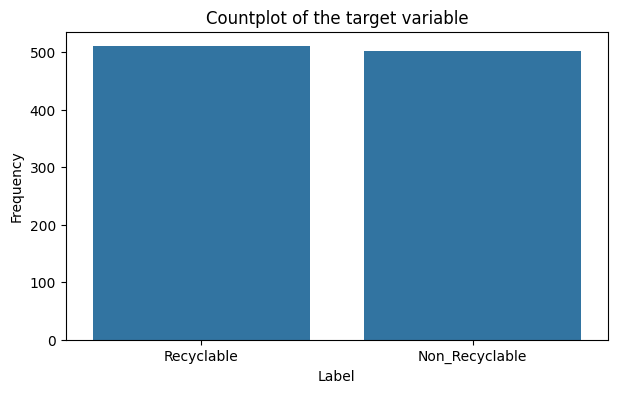

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(x= "label", data=df)
plt.title ("Countplot of the target variable")
plt.xlabel ("Label")
plt.ylabel ("Frequency")
plt.show()

As we can observe, the dataset has no class imbalance

## Visualization of Mean RGB color features

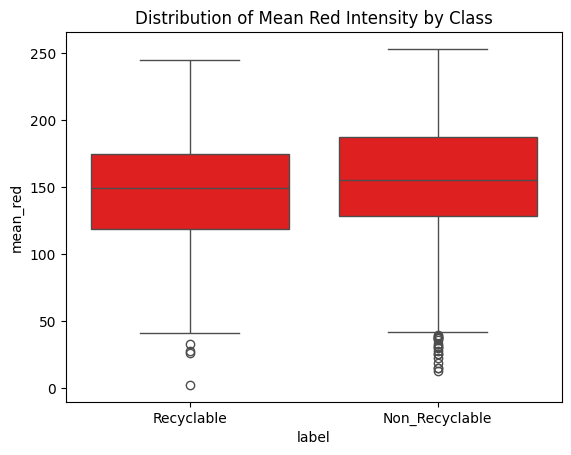

In [ ]:
plt.figure()
sns.boxplot(x='label', y='mean_red', data=df, color= 'red')
plt.title("Distribution of Mean Red Intensity by Class")
plt.show()

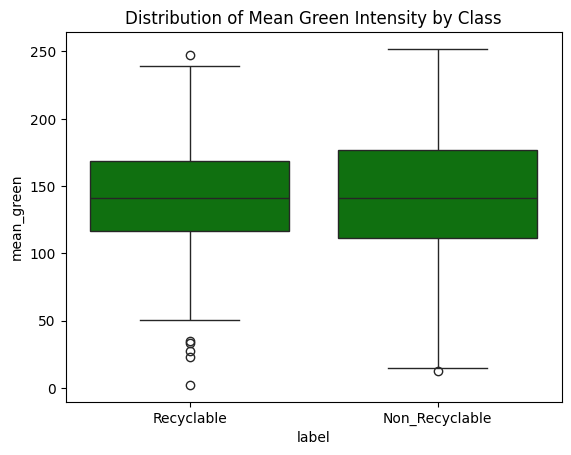

In [ ]:
plt.figure()
sns.boxplot(x='label', y='mean_green', data=df, color="green")
plt.title("Distribution of Mean Green Intensity by Class")
plt.show()

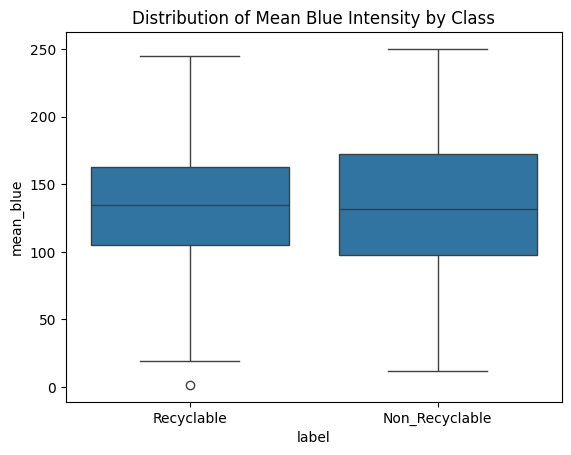

In [ ]:
plt.figure()
sns.boxplot(x='label', y='mean_blue', data=df)
plt.title("Distribution of Mean Blue Intensity by Class")
plt.show()

The mean RGB intensity features (red, green, and blue) show similar central tendencies for both classes, with considerable overlap in their interquartile ranges. This indicates that color information alone is not sufficient to distinguish recyclable from non-recyclable waste

## GLCM Contrast feature Visualization

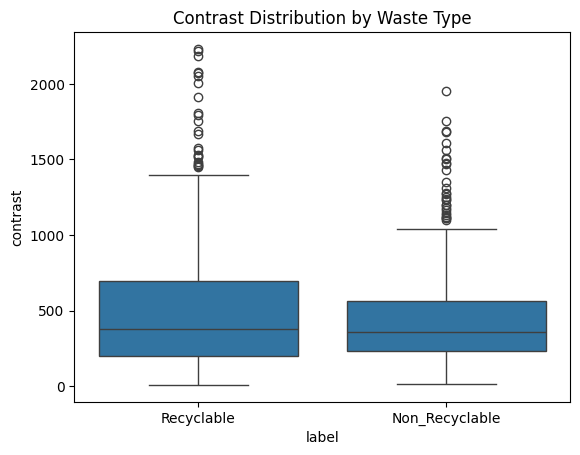

In [ ]:
plt.figure()
sns.boxplot(x='label', y='contrast', data=df)
plt.title("Contrast Distribution by Waste Type")
plt.show()

The GLCM contrast feature demonstrates noticeable variability in both classes, with recyclable waste showing higher extreme values. This indicates stronger intensity differences in recyclable materials such as plastics, metals, and glass. However, the substantial overlap suggests that contrast alone is insufficient for strong class separation but is informative when combined with other features.

# GLCM Homogeniety feature Visualization

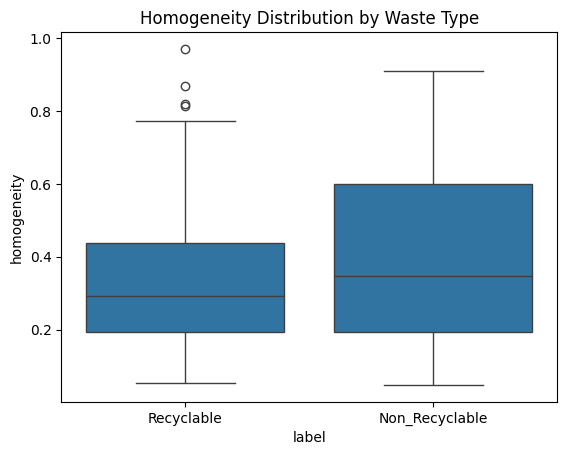

In [ ]:
plt.figure()
sns.boxplot(x='label', y='homogeneity', data=df)
plt.title("Homogeneity Distribution by Waste Type")
plt.show()

The GLCM homogeneity feature displays moderate separation between the two classes. Non-recyclable waste generally shows slightly higher median homogeneity values, implying more uniform local texture patterns.

## GLCM Energy Distribution by Waste Type

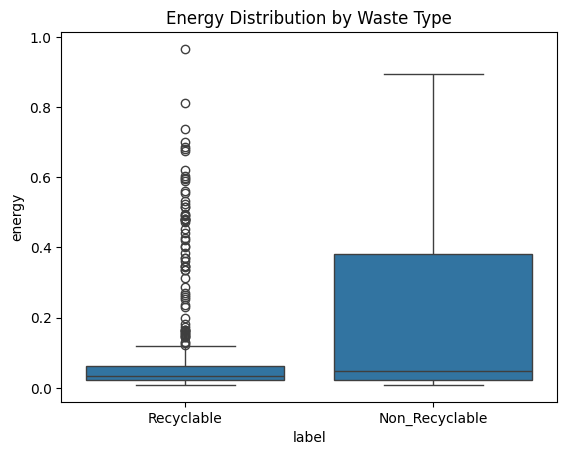

In [ ]:
plt.figure()
sns.boxplot(x='label', y='energy', data=df)
plt.title("Energy Distribution by Waste Type")
plt.show()

The GLCM energy feature shows a clear difference in spread between the two classes. Non-recyclable waste exhibits a wider range of energy values, indicating higher variability in texture uniformity. Recyclable waste, on the other hand, tends to have lower median energy values with several high-value outliers. This suggests that recyclable materials often possess more repetitive or structured textures, while non-recyclable items are visually more heterogeneous.

# Removal of Outliers and Scaling of Data

In [ ]:
X=df.drop("label", axis=1)
y=df["label"]
def iqr_capping(X):
    # Ensure DataFrame for column-wise operation
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)

    X_capped = X.copy()

    for col in X_capped.columns:
        Q1 = X_capped[col].quantile(0.25)
        Q3 = X_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        X_capped[col] = X_capped[col].clip(lower_bound, upper_bound)

    return X_capped
X= iqr_capping(X)
scalar= StandardScaler()
X = scalar.fit_transform(X)


In [ ]:
X_scaled = pd.DataFrame(X)
df_merged = pd.concat([X_scaled, y], axis=1)
df_merged.to_csv("cleaned_data.csv", index=False)

## Train Test Split
Before applying machine learning algorithms, the dataset was divided into training and testing subsets using the train–test split approach. This step is essential to evaluate how well the trained models generalize to unseen data. In this project, the dataset was split such that a majority portion was used for training the models, while the remaining portion was reserved for testing.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
n_components_lda= min(X.shape[1], len(np.unique(y)) - 1)
lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)
print("\n--- LDA Results ---")
print(f"Transformed training data shape: {X_train_lda.shape}")
# Explained variance in LDA relates to class separability
print("Explained variance ratio by each component (class separation):",lda.explained_variance_ratio_)




--- LDA Results ---
Transformed training data shape: (707, 1)
Explained variance ratio by each component (class separation): [1.]


## Linear Discriminant Analysis
LDA is a supervised dimensionality reduction technique that maximizes class separability. Considering the existence of more than 3000 extracted features, we have opted for Linear Discriminant analysis (LDA). We obtain a single feature which maximizes class separability.

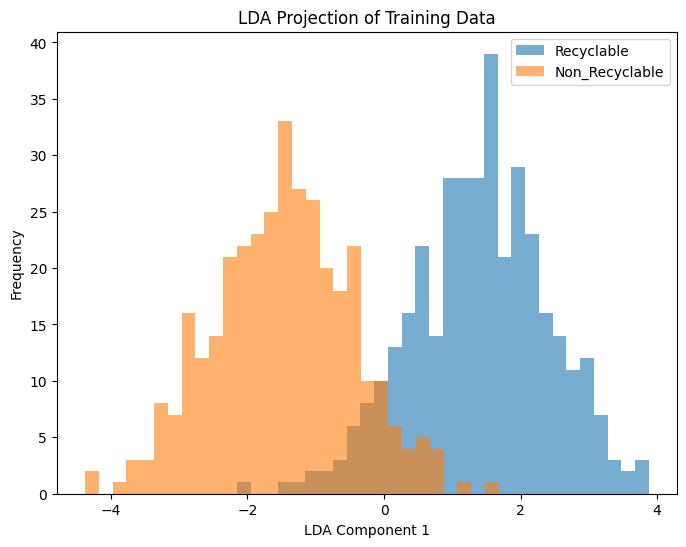

In [ ]:
def plot_lda(X_lda, y, title):
    plt.figure(figsize=(8,6))
    plt.hist(X_lda[y=='Recyclable'], bins=30, alpha=0.6, label='Recyclable')
    plt.hist(X_lda[y=='Non_Recyclable'], bins=30, alpha=0.6, label='Non_Recyclable')
    plt.xlabel("LDA Component 1")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.legend()
    plt.show()
plot_lda(X_train_lda, y_train, 'LDA Projection of Training Data')

# Model 1: Logistic Regression
Logistic Regression works by modeling the probability of an instance belonging to a particular class using a logistic (sigmoid) function. It is well-suited for binary classification problems and provides probabilistic outputs, making it easy to interpret the influence of input features.

Accuracy Score: 0.6414473684210527
                precision    recall  f1-score   support

Non_Recyclable       0.64      0.68      0.66       157
    Recyclable       0.64      0.60      0.62       147

      accuracy                           0.64       304
     macro avg       0.64      0.64      0.64       304
  weighted avg       0.64      0.64      0.64       304



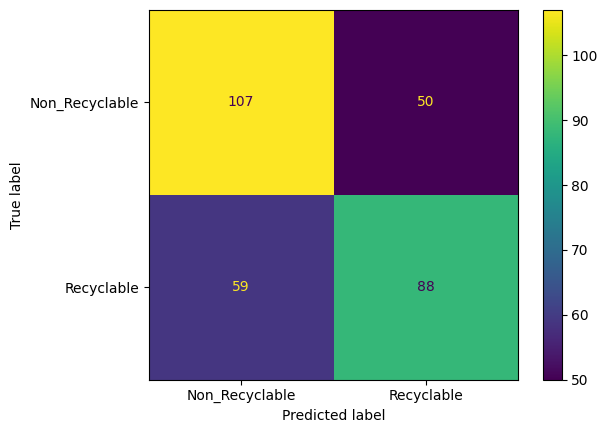

In [ ]:
model1=LogisticRegression(max_iter=1000)
model1.fit(X_train_lda, y_train)
y_pred1=model1.predict(X_test_lda)
acc_score= accuracy_score(y_test, y_pred1)
print("Accuracy Score:", acc_score)
print(classification_report(y_test, y_pred1))
cm = confusion_matrix(y_test, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels=model1.classes_)
disp.plot()
plt.show()


Logistic Regression achieved an accuracy of 64.14\%. The model showed balanced precision for both recyclable and non-recyclable classes, but the recall for recyclable waste was slightly lower. This indicates that Logistic Regression is able to capture general patterns in the data but has limitations in handling complex variations present in image-based features.

# Model 2: Decision Tree
Decision Tree is a rule-based model that recursively splits the dataset based on feature values to maximize class purity. Its tree-like structure makes it highly interpretable.

Accuracy Score: 0.6480263157894737
                precision    recall  f1-score   support

Non_Recyclable       0.66      0.67      0.66       157
    Recyclable       0.64      0.63      0.63       147

      accuracy                           0.65       304
     macro avg       0.65      0.65      0.65       304
  weighted avg       0.65      0.65      0.65       304



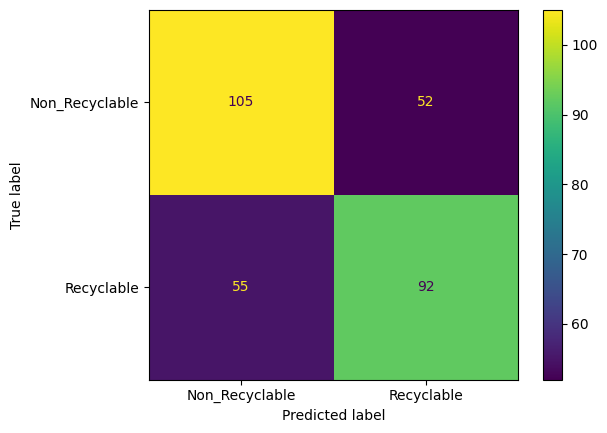

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
model2 = DecisionTreeClassifier(criterion='gini',max_depth=5, random_state=42)
model2.fit(X_train_lda, y_train)
y_pred2 = model2.predict(X_test_lda)
acc_score = accuracy_score(y_test, y_pred2)
print("Accuracy Score:", acc_score)
print(classification_report(y_test, y_pred2))
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels=model2.classes_)
disp.plot()
plt.show()

The Decision Tree model performed slightly better with an accuracy of 64.80\%, which was the highest among the three models. It showed improved balance between precision and recall for both classes. Since Decision Trees can model non-linear relationships, they were better able to separate recyclable and non-recyclable waste based on color and texture features extracted from the images.

# Model 3: Random Forests
Random Forest is an ensemble method that combines multiple decision trees to improve generalization and reduce overfitting, making it more robust to noise and feature variability.

Accuracy Score: 0.6447368421052632
                precision    recall  f1-score   support

Non_Recyclable       0.65      0.66      0.66       157
    Recyclable       0.63      0.63      0.63       147

      accuracy                           0.64       304
     macro avg       0.64      0.64      0.64       304
  weighted avg       0.64      0.64      0.64       304



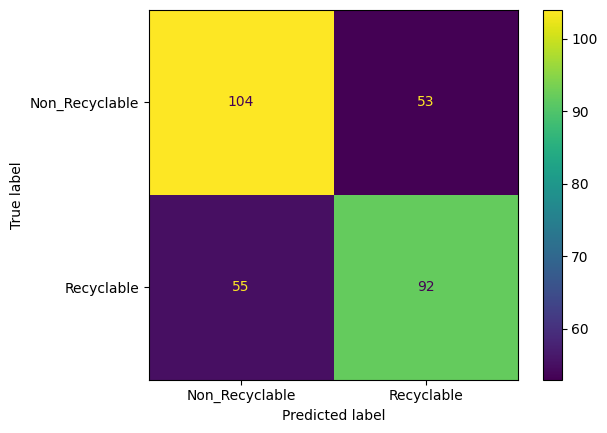

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    criterion="gini",
    max_depth=4,
    random_state=42
)

rf.fit(X_train_lda, y_train)
y_pred_rf = rf.predict(X_test_lda)
acc_score = accuracy_score(y_test, y_pred_rf)
print("Accuracy Score:", acc_score)
print(classification_report(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels=rf.classes_)
disp.plot()
plt.show()

Random Forest achieved an accuracy of 64.47\%, which is comparable to the other models. The precision and recall values for both classes were well balanced, indicating stable performance. However, the improvement over Decision Tree was minimal. This suggests that increasing model complexity alone does not significantly improve performance when using handcrafted features.